In [2]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt # for plotting
%matplotlib inline


In [3]:
# read all the words
with open('names.txt', 'r') as f:
    words = f.read().splitlines()

In [4]:
# build the vocabulary of characters and mappings to/from integers
chars = sorted(list(set("".join(words))))
stoi = { ch: i + 1 for i, ch in enumerate(chars) }
stoi['.'] = 0
itos = { i: ch for ch, i in stoi.items() }
vocab_size = len(itos)
print(itos)

{1: 'a', 2: 'b', 3: 'c', 4: 'd', 5: 'e', 6: 'f', 7: 'g', 8: 'h', 9: 'i', 10: 'j', 11: 'k', 12: 'l', 13: 'm', 14: 'n', 15: 'o', 16: 'p', 17: 'q', 18: 'r', 19: 's', 20: 't', 21: 'u', 22: 'v', 23: 'w', 24: 'x', 25: 'y', 26: 'z', 0: '.'}


In [5]:
block_size = 3 # context length: how many characters do we take to predict the next one
# build the dataset
def build_dataset(words):
    X, Y = [], []
    for w in words:
        context = [0] * block_size
        for ch in w + '.':
            ix = stoi[ch]
            X.append(context)
            Y.append(ix)
            context = context[1:] + [ix]
    X = torch.tensor(X)
    Y = torch.tensor(Y)
    return X, Y

import random
random.seed(42)
random.shuffle(words)
n1 = int(0.8 * len(words))
n2 = int(0.9 * len(words))

Xtr, Ytr = build_dataset(words[:n1])  # 80%
Xdev, Ydev = build_dataset(words[n1:n2])  # 10%
Xte, Yte = build_dataset(words[n2:])  # 10%


In [6]:
# MLP revisited
n_embd = 10 # the dimensionality of the character embedding vectors 
n_hidden = 200 

# Init Parameters
g = torch.Generator().manual_seed(2147483647) 
C = torch.randn((vocab_size, n_embd), generator=g)
W1 = torch.randn((n_embd * block_size, n_hidden), generator=g)
b1 = torch.randn(n_hidden, generator=g)
W2 = torch.randn((n_hidden, vocab_size), generator=g)
b2 = torch.randn(vocab_size, generator=g)
parameters = [C, W1, b1, W2, b2]
for p in parameters:
    p.requires_grad = True

print(sum(p.numel() for p in parameters)) # number of parameters in total


11897


In [7]:
# same optimization as last time
max_steps = 200000
batch_size = 32
lossi = []
for i in range(max_steps):
    # minibatch construct
    ix = torch.randint(0, Xtr.shape[0], (batch_size,), generator=g) 
    Xb = Xtr[ix]
    Yb = Ytr[ix]
    # forward pass
    emb = C[Xb] # embed the characters into vectors
    embcat = emb.view(emb.shape[0], -1)  # concatenate the vectors 
    hpreact = embcat @ W1 + b1 # hidden layer pre-activation
    h = torch.tanh(hpreact) # hidden layer 
    logits = h @ W2 + b2 # output layer 
    loss = F.cross_entropy(logits, Yb) # loss function
    # backward pass
    for p in parameters:
        p.grad = None
    loss.backward()
    
    # update
    lr = 0.1 if i < 100000 else 0.01 # step learning rate decay
    for p in parameters:
        p.data -= lr * p.grad

    # track stats
    if i % 1000 == 0: # print every once in a while
        print(f'{i:7d} / {max_steps:7d} {loss.item():.4f}')
    lossi.append(loss.log10().item())



      0 /  200000 27.8817
   1000 /  200000 4.0136
   2000 /  200000 2.9950
   3000 /  200000 2.9579
   4000 /  200000 2.3792
   5000 /  200000 2.4390
   6000 /  200000 2.3733
   7000 /  200000 2.7908
   8000 /  200000 2.4839
   9000 /  200000 2.5200
  10000 /  200000 2.8138
  11000 /  200000 2.0352
  12000 /  200000 2.4150
  13000 /  200000 2.4217
  14000 /  200000 2.9007
  15000 /  200000 2.3040
  16000 /  200000 2.5715
  17000 /  200000 2.7462
  18000 /  200000 2.4824
  19000 /  200000 2.4733
  20000 /  200000 2.5218
  21000 /  200000 2.5537
  22000 /  200000 2.0815
  23000 /  200000 2.1454
  24000 /  200000 3.1150
  25000 /  200000 2.2707
  26000 /  200000 2.3511
  27000 /  200000 2.6000
  28000 /  200000 2.3446
  29000 /  200000 3.0862
  30000 /  200000 2.7874
  31000 /  200000 2.7719
  32000 /  200000 2.5788
  33000 /  200000 2.3486
  34000 /  200000 2.1745
  35000 /  200000 2.5503
  36000 /  200000 2.1941
  37000 /  200000 2.2459
  38000 /  200000 2.8807
  39000 /  200000 2.0091

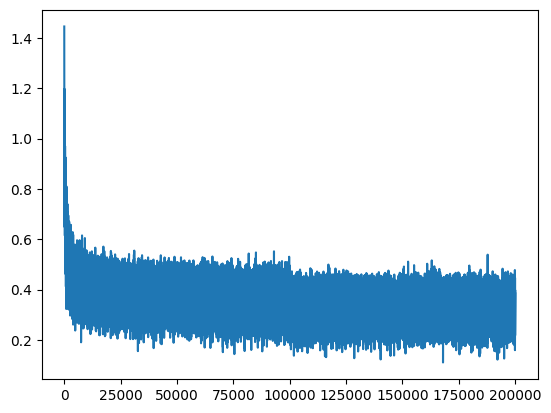

In [8]:
plt.plot(lossi)

In [9]:
@torch.no_grad() # this decorator disables gradient tracking
def split_loss(split):
    x, y = {
        'train': (Xtr, Ytr),
        'val': (Xdev, Ydev),
        'test': (Xte, Yte),
    }[split] 
    emb = C[x] # (N, block_size, n_embd)
    embcat = emb.view(emb.shape[0], -1) # concat into (N, block_size * n_embd)
    hpreact = embcat @ W1 + b1 # (N, n_hidden)
    h = torch.tanh(hpreact) # (N, n_hidden)
    logits = h @ W2 + b2 # (N, vocab_size)
    loss = F.cross_entropy(logits, y)
    print(f'{split} loss: {loss.item():.4f}')
    # return loss.item()

split_loss('train')
split_loss('val')

train loss: 2.1268
val loss: 2.1698


In [10]:
# sample from the model
g = torch.Generator().manual_seed(214748364 + 10)

for _ in range(20):
    out = []
    context = [0] * block_size # initialize the context with all ...
    while True:
        emb = C[torch.tensor([context])] # (1, block_size, n_embd)
        embcat = emb.view(1, -1) # (1, block_size * n_embd)
        hpreact = embcat @ W1 + b1 # (1, n_hidden)
        h = torch.tanh(hpreact) # (1, n_hidden)
        logits = h @ W2 + b2 # (1, vocab_size)
        probs = F.softmax(logits, dim=-1)
        # sample from the distribution
        ix = torch.multinomial(probs, num_samples=1, replacement=True, generator=g).item()
        context = context[1:] + [ix]
        out.append(ix)
        if ix == 0: # end of sentence
            break
    print(''.join(itos[i] for i in out))
    
    

noth.
fadhiey.
codona.
ron.
ory.
zarloreyana.
addix.
gan.
siauriah.
heen.
grudeful.
maurin.
nuor.
isia.
sano.
ansi.
ane.
lock.
onzleyshanarah.
til.


# Reflect on initialization
## detection 1 - improperly configured at initilaization
- the very first initialization: loss is 27.8817 -> then rapidly comes down to 2.8550
- at the initialization: we expect every character has equal probility, which is 1.0/27, 
- the main problem is that in the very beginning, the logits comes out is very arbitrary, not uniformed -> expected to be 0.
    1. b2: 0
    2. scale W2 by 0.1
    3. outcome: the loss doesn't look like a hocky stick. otherwise, the the first several thousands of iteraions, it's just squashing down the weights.
## detection 2 - the activation of the hidden state is quite active
- observe the h output in the very beginning and consider that the tanh function is a squashing function 
- the dead neurons can happen:
    1. initialization: the bias and the weights settings
    2. the high learning rate 
- analysis for current code: `hpreact = embcat @ W1 + b1` and hpreact is too far off from zero and that's causing the isssue. 
- solution
    - scale down b1 : `b1 = torch.randn(n_hidden, generator=h) * 0.01` -> adding a bit of entropy to make it a bit of variation and diversity in the original
    - scale down W1 by multiply 0.1


## detection 1 - improperly configured at initilaization
- Explain on why only set W2 to small numbers instead of 0
    - used for symmetry breaking

In [11]:
# expected loss in initializaiton
-torch.tensor(1.0/27).log().item() 

3.295836925506592

In [12]:
# 4-dimensional exmaple of the issue
logits = torch.tensor([0.0, 0.0, 0.0, 0.0])
probs = torch.softmax(logits, dim=0) # it's one dimensional, so use dim=0 to do normalization, if it's (N, C), use dim=1 which means to normalize each row. and dim=-1 means to normalize the last dimension
loss = -probs[2].log()
probs, loss

(tensor([0.2500, 0.2500, 0.2500, 0.2500]), tensor(1.3863))

In [13]:
# adjust 4-dimensional example to be random
logits = torch.randn(4, generator=g)
probs = torch.softmax(logits, dim=0)
loss = -probs[2].log()
logits,probs, loss


(tensor([0.1052, 0.0242, 0.9251, 1.9678]),
 tensor([0.0940, 0.0867, 0.2135, 0.6057]),
 tensor(1.5441))

In [14]:
# after enhancement
# MLP revisited
n_embd = 10 # the dimensionality of the character embedding vectors 
n_hidden = 200 

# Init Parameters
g = torch.Generator().manual_seed(2147483647) 
C = torch.randn((vocab_size, n_embd), generator=g)
W1 = torch.randn((n_embd * block_size, n_hidden), generator=g)
b1 = torch.randn(n_hidden, generator=g)
W2 = torch.randn((n_hidden, vocab_size), generator=g) * 0.01 # scale down the output layer
b2 = torch.randn(vocab_size, generator=g) * 0 # do not add bias to the output layer in the beginning
parameters = [C, W1, b1, W2, b2]
for p in parameters:
    p.requires_grad = True

print(sum(p.numel() for p in parameters)) # number of parameters in total


11897


In [15]:
# same optimization as last time
max_steps = 200000
batch_size = 32
lossi = []
for i in range(max_steps):
    # minibatch construct
    ix = torch.randint(0, Xtr.shape[0], (batch_size,), generator=g) 
    Xb = Xtr[ix]
    Yb = Ytr[ix]
    # forward pass
    emb = C[Xb] # embed the characters into vectors
    embcat = emb.view(emb.shape[0], -1)  # concatenate the vectors 
    hpreact = embcat @ W1 + b1 # hidden layer pre-activation
    h = torch.tanh(hpreact) # hidden layer 
    logits = h @ W2 + b2 # output layer 
    loss = F.cross_entropy(logits, Yb) # loss function
    # backward pass
    for p in parameters:
        p.grad = None
    loss.backward()
    
    # update
    lr = 0.1 if i < 100000 else 0.01 # step learning rate decay
    for p in parameters:
        p.data -= lr * p.grad

    # track stats
    if i % 1000 == 0: # print every once in a while
        print(f'{i:7d} / {max_steps:7d} {loss.item():.4f}')
    lossi.append(loss.log10().item())
    break



      0 /  200000 3.3221


## detection 2 - the activation of the hidden state

In [16]:
print(h.shape)
print(h.view(-1).shape) # strech the hidden state into a 1D vector
print(h.view(-1).tolist()) # convert the 1D vector to a list

torch.Size([32, 200])
torch.Size([6400])
[0.8100225329399109, -0.8996701836585999, -0.999309241771698, 0.9980825185775757, -0.6508480906486511, -0.6897538900375366, -0.961920976638794, -0.9999876022338867, -0.34206923842430115, 0.999920666217804, 0.9999915957450867, -0.9980642199516296, 0.9876819252967834, 0.8998492956161499, 0.8862372636795044, 0.7360543012619019, -0.9959285855293274, -0.981837809085846, -0.9892273545265198, 0.9997955560684204, -0.9220332503318787, -0.8541553616523743, 0.06397326290607452, 0.9999996423721313, 0.9979971051216125, -0.9949458837509155, 0.9996280670166016, -0.9998515844345093, 0.6444540619850159, 0.7554436922073364, -0.9997296929359436, 0.9996114373207092, 0.9912618398666382, 0.9449752569198608, 0.9999983310699463, -0.9999998211860657, 0.9999754428863525, -0.9999991059303284, 1.0, -0.556519091129303, 0.9787917733192444, -0.9885086417198181, 0.9983248710632324, -0.9999771118164062, -0.036519937217235565, 0.9999677538871765, 0.9990684986114502, -0.725018024

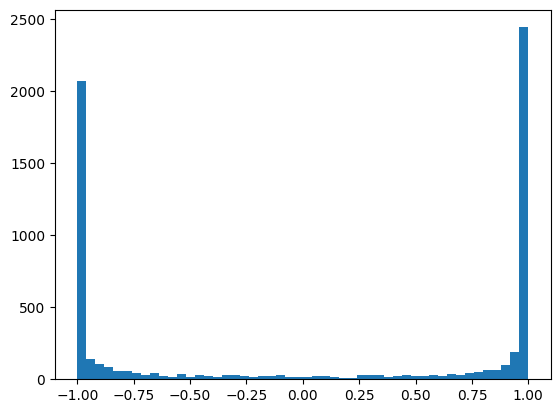

In [17]:
plt.hist(h.view(-1).tolist(), bins=50); # plot to histgram with 50 bins, semicolons to suppress the output.
# from the histogram, we can see that the tanh is very active in the beginning.

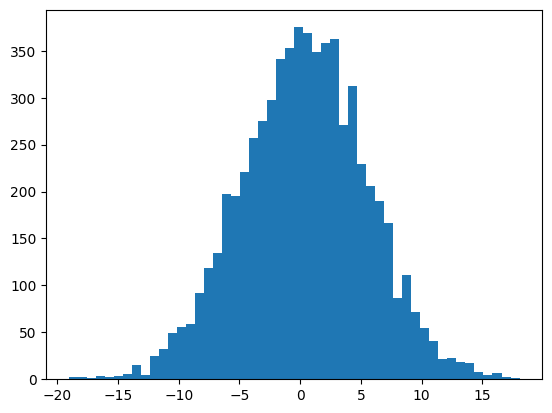

In [19]:
# next step is to check the hreact
plt.hist(hpreact.view(-1).tolist(), bins=50);
# from the histogram, we can see that the distribution of the hreact is very boroad.


In [ ]:
# next steps, look at how backpropagate the gradient on tanh
# example code
import math

def tanh(data):
    x = data
    t = (math.exp(x) - math.exp(-x)) / (math.exp(x) + math.exp(-x))
    return t

def tanh_grad(data, grad_output):
    x = data
    t = tanh(x)
    return grad_output * (1 - t**2)

# problem here:
# if t is 1 or -1, then the gradient is 0, which means the gradient is not backpropagated.
# if t is 0, then the grad_output is passed through, which means the tanh is not active.

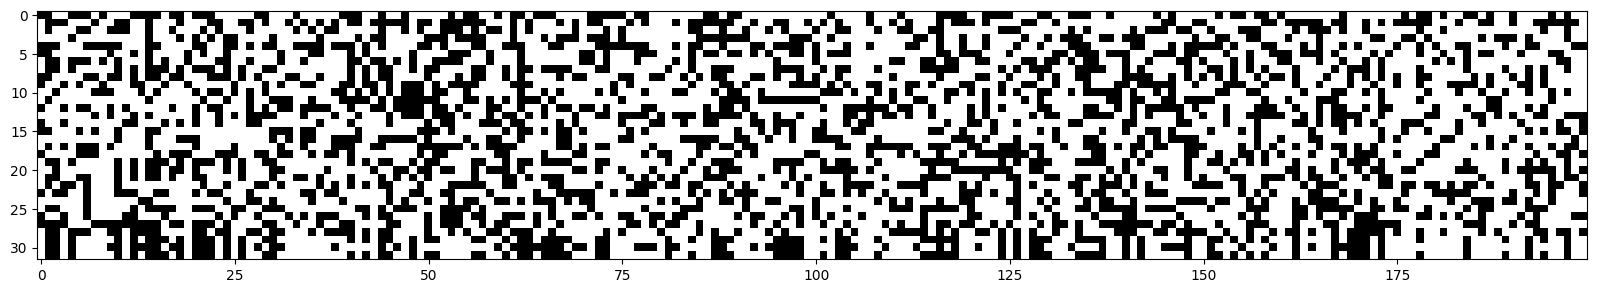

In [ ]:
# next step:
plt.figure(figsize=(20, 10))
# 用 h.abs() > 0.99 做掩码，imshow 画成灰度网格图，nearest 让每个单元格边界清楚，用来可视化饱和激活的分布。
plt.imshow(h.abs() > 0.99, cmap='gray', interpolation='nearest') # boolean tensor, true -> white, false -> black
# y axis: the example index (32 in one batch), x axis: the hidden unit index (200 in total)
# if the entire column is white, then we will be in trouble. -> dead neuron, never learn.
# and it happens for all non-linear activations: sigmoid, relu, tanh, etc.

## Fix problem 2


In [42]:
# after enhancement
# MLP revisited
n_embd = 10 # the dimensionality of the character embedding vectors 
n_hidden = 200 

# Init Parameters
g = torch.Generator().manual_seed(2147483647) 
C = torch.randn((vocab_size, n_embd), generator=g)
W1 = torch.randn((n_embd * block_size, n_hidden), generator=g) * 0.2 # scale down the input layer
b1 = torch.randn(n_hidden, generator=g) * 0.01 # scale down the bias
W2 = torch.randn((n_hidden, vocab_size), generator=g) * 0.01 # scale down the output layer
b2 = torch.randn(vocab_size, generator=g) * 0 # do not add bias to the output layer in the beginning
parameters = [C, W1, b1, W2, b2]
for p in parameters:
    p.requires_grad = True

print(sum(p.numel() for p in parameters)) # number of parameters in total

11897


In [43]:
# same optimization as last time
max_steps = 200000
batch_size = 32
lossi = []
for i in range(max_steps):
    # minibatch construct
    ix = torch.randint(0, Xtr.shape[0], (batch_size,), generator=g) 
    Xb = Xtr[ix]
    Yb = Ytr[ix]
    # forward pass
    emb = C[Xb] # embed the characters into vectors
    embcat = emb.view(emb.shape[0], -1)  # concatenate the vectors 
    hpreact = embcat @ W1 + b1 # hidden layer pre-activation
    h = torch.tanh(hpreact) # hidden layer 
    logits = h @ W2 + b2 # output layer 
    loss = F.cross_entropy(logits, Yb) # loss function
    # backward pass
    for p in parameters:
        p.grad = None
    loss.backward()
    
    # update
    lr = 0.1 if i < 100000 else 0.01 # step learning rate decay
    for p in parameters:
        p.data -= lr * p.grad

    # track stats
    if i % 1000 == 0: # print every once in a while
        print(f'{i:7d} / {max_steps:7d} {loss.item():.4f}')
    lossi.append(loss.log10().item())
    # break

      0 /  200000 3.3135
   1000 /  200000 2.1560
   2000 /  200000 2.3728
   3000 /  200000 2.1645
   4000 /  200000 2.1078
   5000 /  200000 2.2611
   6000 /  200000 2.1219
   7000 /  200000 2.4237
   8000 /  200000 1.9729
   9000 /  200000 2.1180
  10000 /  200000 2.1648
  11000 /  200000 1.8275
  12000 /  200000 2.1509
  13000 /  200000 2.1969
  14000 /  200000 2.5895
  15000 /  200000 1.9729
  16000 /  200000 2.3832
  17000 /  200000 2.2661
  18000 /  200000 1.9382
  19000 /  200000 2.2800
  20000 /  200000 2.3061
  21000 /  200000 2.5016
  22000 /  200000 1.9435
  23000 /  200000 1.9305
  24000 /  200000 2.6276
  25000 /  200000 2.3065
  26000 /  200000 2.3542
  27000 /  200000 2.4404
  28000 /  200000 2.0498
  29000 /  200000 2.4964
  30000 /  200000 2.4541
  31000 /  200000 2.1754
  32000 /  200000 2.4052
  33000 /  200000 2.2972
  34000 /  200000 1.9050
  35000 /  200000 2.1970
  36000 /  200000 2.2206
  37000 /  200000 2.0670
  38000 /  200000 2.5393
  39000 /  200000 2.0746


In [44]:
split_loss('train')
split_loss('val')

train loss: 2.0356
val loss: 2.1027


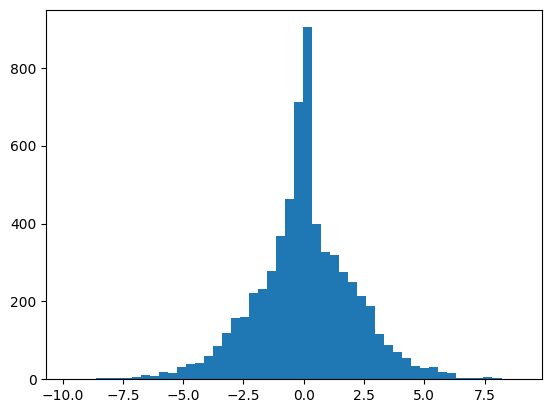

In [45]:
plt.hist(hpreact.view(-1).tolist(), bins=50);

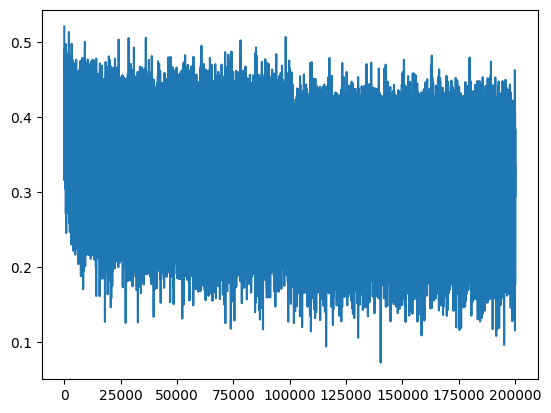

In [46]:
plt.plot(lossi)

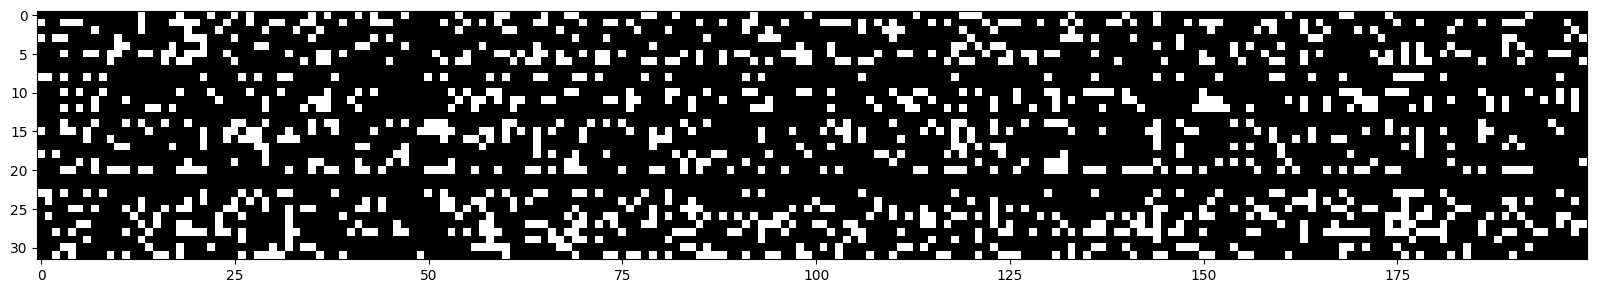

In [47]:
# next step:
plt.figure(figsize=(20, 10))
# 用 h.abs() > 0.99 做掩码，imshow 画成灰度网格图，nearest 让每个单元格边界清楚，用来可视化饱和激活的分布。
plt.imshow(h.abs() > 0.99, cmap='gray', interpolation='nearest') # boolean tensor, true -> white, false -> black

# Explain on the magic numbers

tensor(-0.0131) tensor(1.0016)
tensor(-0.0011) tensor(1.0171)


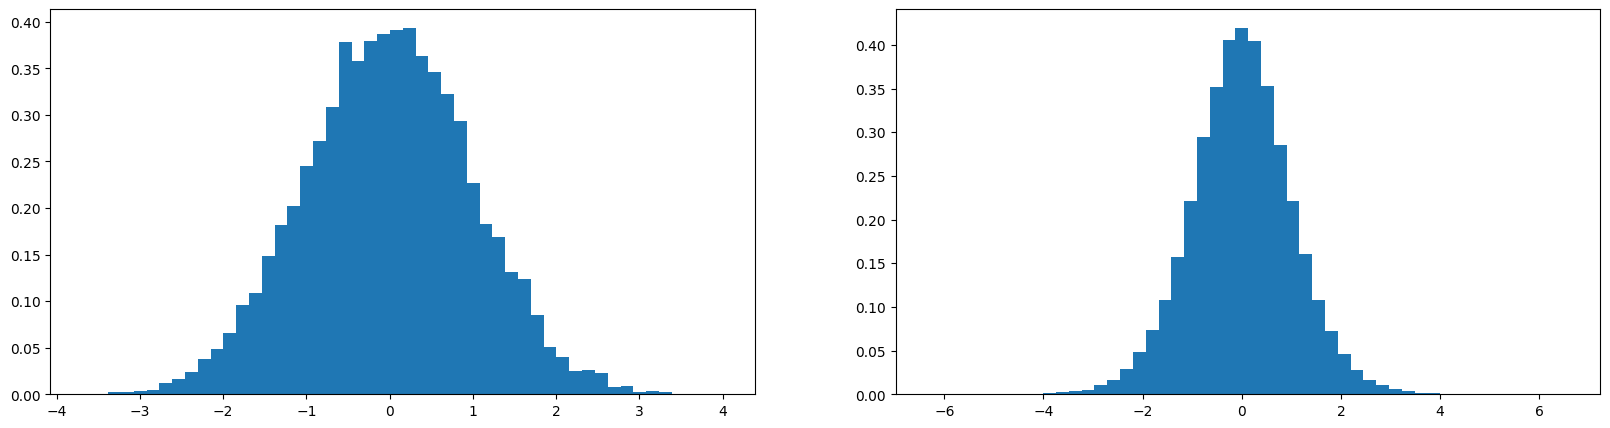

In [50]:
# motivation of the discuss
x = torch.randn(1000, 10)
w = torch.randn(10, 200) / 10 ** 0.5
y = x @ w
print(x.mean(), x.std())
print(y.mean(), y.std()) # the standard deviation of the output is larger than x which means the output is more spread out than the input
plt.figure(figsize=(20, 5))
plt.subplot(121)
plt.hist(x.view(-1).tolist(), 50, density=True);
plt.subplot(122)
plt.hist(y.view(-1).tolist(),50, density=True);



## How do we scale the W to preserve this distribution to remain the guassion
- so we can try with muptiply W by some number to do the scaling to do the observation
- by mathimatically, we know that W / the square root of the fan in 
- so we can do mulitiplication of W1 by (5/3)/((n_embd * block_size)**0.5)

# Introdcution of Batch Normalization
- make it possible to train very deep neuro networks quite reliably
- if we directly add batch normalization to every batch `hpreact = (hpreact - hpreact.mean(0, keepdim=True)) / hpreact.std(0, keepdim=True)` we won't have a good result becuase we only want these to be roughly gaussian at initialization

In [56]:
# MLP revisited
n_embd = 10 # the dimensionality of the character embedding vectors 
n_hidden = 200 # the number of hidden units

# Init Parameters
g = torch.Generator().manual_seed(2147483647) # for reproducibility 
C = torch.randn((vocab_size, n_embd), generator=g) # the embedding matrix
W1 = torch.randn((n_embd * block_size, n_hidden), generator=g)  * (5/3)/((n_embd * block_size)**0.5) # the weight matrix of the hidden layer
b1 = torch.randn(n_hidden, generator=g) * 0.01  # the bias of the hidden layer
W2 = torch.randn((n_hidden, vocab_size), generator=g) * 0.01 # the weight matrix of the output layer
b2 = torch.randn(vocab_size, generator=g) * 0 # the bias of the output layer

bngain = torch.ones((1, n_hidden)) # the gain of the batch normalization
bnbias = torch.zeros((1, n_hidden)) # the bias of the batch normalization

parameters = [C, W1, b1, W2, b2, bngain, bnbias]
print(sum(p.numel() for p in parameters)) # the total number of parameters
for p in parameters:
    p.requires_grad = True

12297


In [55]:
# inspection
print(hpreact.shape)
print(hpreact.mean(0, keepdim=True).shape) # doing the mean over all the examples in the batch
print(hpreact.std(0, keepdim=True).shape) # doing the std over all the examples in the batch

torch.Size([32, 200])
torch.Size([1, 200])
torch.Size([1, 200])


      0 /  200000 3.3147
   1000 /  200000 2.1945
   2000 /  200000 2.3061
   3000 /  200000 2.2337
   4000 /  200000 2.1661
   5000 /  200000 2.3550
   6000 /  200000 2.1222
   7000 /  200000 2.4549
   8000 /  200000 2.0116
   9000 /  200000 2.2276
  10000 /  200000 2.1984
  11000 /  200000 1.8837
  12000 /  200000 2.2050
  13000 /  200000 2.2054
  14000 /  200000 2.6501
  15000 /  200000 2.0817
  16000 /  200000 2.4526
  17000 /  200000 2.2701
  18000 /  200000 2.0249
  19000 /  200000 2.3733
  20000 /  200000 2.3375
  21000 /  200000 2.4851
  22000 /  200000 1.9193
  23000 /  200000 1.9813
  24000 /  200000 2.5391
  25000 /  200000 2.3289
  26000 /  200000 2.3917
  27000 /  200000 2.4123
  28000 /  200000 2.0773
  29000 /  200000 2.6299
  30000 /  200000 2.4359
  31000 /  200000 2.2457
  32000 /  200000 2.4601
  33000 /  200000 2.3236
  34000 /  200000 1.9366
  35000 /  200000 2.3067
  36000 /  200000 2.1359
  37000 /  200000 2.0240
  38000 /  200000 2.6379
  39000 /  200000 2.1167


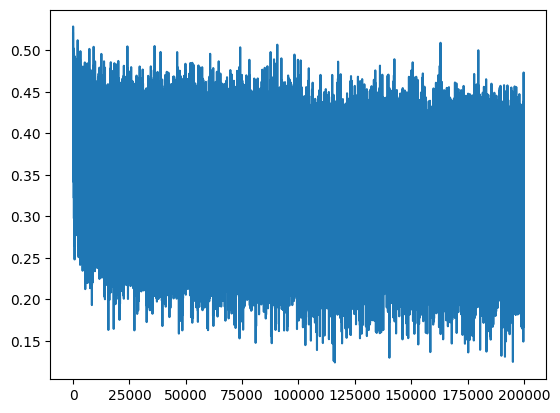

In [57]:
# same optimization as last time
max_steps = 200000
batch_size = 32
lossi = []
for i in range(max_steps):
    # minibatch construct
    ix = torch.randint(0, Xtr.shape[0], (batch_size,), generator=g) 
    Xb, Yb = Xtr[ix], Ytr[ix]
    # forward pass
    emb = C[Xb] # embed the characters into vectors
    embcat = emb.view(emb.shape[0], -1)  # concatenate the vectors 
    hpreact = embcat @ W1 + b1 # hidden layer pre-activation -> expect the distribution of the hpreact to be close to the normal distribution
    # batch normalization
    hpreact = bngain * (hpreact - hpreact.mean(0, keepdim=True)) / hpreact.std(0, keepdim=True) + bnbias
    h = torch.tanh(hpreact) # hidden layer 
    logits = h @ W2 + b2 # output layer 
    loss = F.cross_entropy(logits, Yb) # loss function
    # backward pass
    for p in parameters:
        p.grad = None
    loss.backward()
    
    # update
    lr = 0.1 if i < 100000 else 0.01 # step learning rate decay
    for p in parameters:
        p.data -= lr * p.grad

    # track stats
    if i % 1000 == 0: # print every once in a while
        print(f'{i:7d} / {max_steps:7d} {loss.item():.4f}')
    lossi.append(loss.log10().item())

plt.plot(lossi)



In [58]:
@torch.no_grad()
def split_loss(split):
    x, y = {
        'train': (Xtr, Ytr),
        'val': (Xdev, Ydev),
        'test': (Xte, Yte),
    }[split] 
    emb = C[x] # (N, block_size, n_embd)
    embcat = emb.view(emb.shape[0], -1) # concat into (N, block_size * n_embd)
    hpreact = embcat @ W1 + b1 # (N, n_hidden)
    hpreact = bngain * (hpreact - hpreact.mean(0, keepdim=True)) / hpreact.std(0, keepdim=True) + bnbias
    h = torch.tanh(hpreact) # (N, n_hidden)
    logits = h @ W2 + b2 # (N, vocab_size)
    loss = F.cross_entropy(logits, y)
    print(f'{split} loss: {loss.item():.4f}')
    return loss.item()

In [59]:
split_loss('train')
split_loss('val')

train loss: 2.0668
val loss: 2.1048


2.104844808578491